# Clasificador PLS vs. lenguaje técnico

Cuaderno para entrenar y evaluar un clasificador binario que distingue resúmenes en lenguaje sencillo (PLS) de texto médico técnico.

## Tabla de contenidos
- [1. Preparación y librerías](#1-preparacion-y-librerias)
- [2. Configuración del proyecto](#2-configuracion-del-proyecto)
- [3. Utilidades de apoyo](#3-utilidades-de-apoyo)
- [4. Carga de datos por fuente](#4-carga-de-datos-por-fuente)
- [5. Deduplicación opcional](#5-deduplicacion-opcional)
- [6. Resumen descriptivo](#6-resumen-descriptivo)
- [7. Partición de conjuntos](#7-particion-de-conjuntos)
- [8. Modelos base](#8-modelos-base)
- [9. Entrenamiento y métricas](#9-entrenamiento-y-metricas)
- [10. Curva ROC](#10-curva-roc)
- [11. Palabras y caracteres indicativos](#11-palabras-y-caracteres-indicativos)
- [12. Análisis de errores](#12-analisis-de-errores)
- [13. Exportación del pipeline](#13-exportacion-del-pipeline)
- [14. Demo de inferencia](#14-demo-de-inferencia)


## 1. Preparación y librerías
Importa paquetes de ciencia de datos, modelos clásicos y utilidades de evaluación para mantener todo en un solo lugar.

In [1]:

# === Importaciones principales ===
# Si algo no está instalado, usa:
#   %pip install scikit-learn pandas numpy matplotlib pypdf2
import os
import json
import time
from pathlib import Path
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, accuracy_score, precision_recall_fscore_support)
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import shuffle

from joblib import dump

print('Versions -> pandas', pd.__version__,
      '| numpy', np.__version__,
      '| sklearn loaded | matplotlib ok')


Versions -> pandas 2.3.2 | numpy 1.26.4 | sklearn loaded | matplotlib ok


## 2. Configuración del proyecto
Define rutas de entrada/salida, etiquetas por defecto y banderas de control para reproducir el experimento.

In [5]:

# === CONFIGURACIÓN ===
# Ruta base hacia tu carpeta de datos (ajústala a tu estructura)
BASE_DIR = Path('bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources')  # por ejemplo: Path('/ruta/a/Data Sources')

# Control de parsing opcional de PDFs (requiere PyPDF2)
PARSE_PDFS = False  # True para intentar leer PDFs si no hay .txt
PDF_MIN_CHARS = 200  # descarta páginas muy cortas o no textuales

# Mapeo por fuente -> etiqueta por defecto (si la estructura no provee /pls /non_pls)
#   'pls' -> 1, 'non_pls' -> 0
LABEL_BY_SOURCE_DEFAULT = {
    'Pfizer': 'pls',
    'Trial Summaries': 'pls',
    'ClinicalTrials.gov': 'non_pls'
}
LABEL_TO_INT = {'non_pls': 0, 'pls': 1}

# Fuentes a considerar (ajústalas según las carpetas que realmente tengas)
SOURCES = [
    'Cochrane',
    'Pfizer',
    'Trial Summaries',
    'ClinicalTrials.gov'
]

# Deduplicación: normaliza y elimina duplicados exactos
DEDUPLICATE = True

# Semilla reproducible
RANDOM_STATE = 17

# Proporción de split para las fuentes que no traen 'train/test'
DEFAULT_TEST_SIZE = 0.2

# Carpeta para artefactos de salida
OUTPUT_DIR = Path('./outputs_pls_classifier')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('BASE_DIR =', BASE_DIR.resolve())
print('OUTPUT_DIR =', OUTPUT_DIR.resolve())


BASE_DIR = /Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/bridging-the-gap-in-health-literacy-main/data_collection_and_processing/Data Sources
OUTPUT_DIR = /Users/danielayala/Documents/Daniel Ayala/Study/MaIA/DespliegueSoluciones/outputs_pls_classifier


## 3. Utilidades de apoyo
Agrupa funciones auxiliares para normalizar texto, controlar semillas y manejar transformaciones comunes.

In [6]:

# === Utilidades ===
def read_txt_file(path: Path) -> Optional[str]:
    try:
        text = path.read_text(encoding='utf-8', errors='ignore').strip()
        return text if text else None
    except Exception as e:
        return None

def read_pdf_file(path: Path) -> Optional[str]:
    if not PARSE_PDFS:
        return None
    try:
        from PyPDF2 import PdfReader
    except Exception:
        return None
    try:
        reader = PdfReader(str(path))
        parts = []
        for page in reader.pages:
            txt = page.extract_text() or ''
            if txt and len(txt) >= PDF_MIN_CHARS:
                parts.append(txt)
        text = '\n'.join(parts).strip()
        return text if text else None
    except Exception:
        return None

def iter_texts_in_dir(root: Path, exts=('.txt',)) -> List[Path]:
    paths = []
    for p in root.rglob('*'):
        if p.is_file() and p.suffix.lower() in exts:
            paths.append(p)
    return paths

def normalize_for_dedup(s: str) -> str:
    s = s.lower().strip()
    s = ' '.join(s.split())
    return s

def label_from_folder_name(folder_name: str) -> Optional[str]:
    name = folder_name.lower()
    if 'pls' == name or name.endswith('/pls'):
        return 'pls'
    if 'non_pls' == name or name.endswith('/non_pls'):
        return 'non_pls'
    if name.endswith('pls') and 'non_' not in name:
        return 'pls'
    if 'non_pls' in name:
        return 'non_pls'
    return None


## 4. Carga de datos por fuente
Lee los corpus etiquetados (Cochrane, Pfizer, Trial Summaries, ClinicalTrials.gov) y concatena en un único DataFrame.

In [7]:

# === Carga de datos por fuente ===
def load_cochrane(base_dir: Path) -> List[Dict]:
    out = []
    root = base_dir / 'Cochrane'
    if not root.exists():
        return out

    for subset in ['train', 'test']:
        subset_dir = root / subset
        if not subset_dir.exists():
            continue
        for class_dir in ['pls', 'non_pls']:
            cdir = subset_dir / class_dir
            if not cdir.exists():
                continue
            for p in iter_texts_in_dir(cdir, exts=('.txt',)):
                txt = read_txt_file(p)
                if txt:
                    out.append({
                        'text': txt,
                        'label': class_dir,
                        'source': 'Cochrane',
                        'subset': subset,
                        'path': str(p)
                    })
    return out

def load_pfizer(base_dir: Path) -> List[Dict]:
    out = []
    root = base_dir / 'Pfizer'
    if not root.exists():
        return out

    # Tomamos solo train/test (extraídos como textos). original_pfizer_texts son PDFs.
    for subset in ['train', 'test']:
        subset_dir = root / subset
        if subset_dir.exists():
            for p in iter_texts_in_dir(subset_dir, exts=('.txt',)):
                txt = read_txt_file(p)
                if txt:
                    out.append({
                        'text': txt,
                        'label': LABEL_BY_SOURCE_DEFAULT.get('Pfizer', 'pls'),
                        'source': 'Pfizer',
                        'subset': subset,
                        'path': str(p)
                    })
    # Opcional: intentar leer PDFs originales (si PARSE_PDFS=True)
    orig_dir = root / 'original_pfizer_texts'
    if orig_dir.exists():
        for p in orig_dir.rglob('*.pdf'):
            txt = read_pdf_file(p)
            if txt:
                out.append({
                    'text': txt,
                    'label': LABEL_BY_SOURCE_DEFAULT.get('Pfizer', 'pls'),
                    'source': 'Pfizer',
                    'subset': 'unspecified',
                    'path': str(p)
                })
    return out

def load_trial_summaries(base_dir: Path) -> List[Dict]:
    out = []
    root = base_dir / 'Trial Summaries'
    if not root.exists():
        return out

    # Carpetas con textos extraídos (p.ej., med, alx, etc.)
    text_folders = ['med', 'alx']  # agrega más si existen: 'amg', 'ast', 'csl', 'gsk', 'ins', 'lbi', 'sep', 'viv', etc.
    for tf in text_folders:
        tf_dir = root / tf
        if tf_dir.exists():
            for p in iter_texts_in_dir(tf_dir, exts=('.txt',)):
                txt = read_txt_file(p)
                if txt:
                    out.append({
                        'text': txt,
                        'label': LABEL_BY_SOURCE_DEFAULT.get('Trial Summaries', 'pls'),
                        'source': 'Trial Summaries',
                        'subset': 'unspecified',
                        'path': str(p)
                    })

    # PDFs originales (opcional)
    orig_dir = root / 'original_texts'
    if orig_dir.exists():
        for p in orig_dir.rglob('*.pdf'):
            txt = read_pdf_file(p)
            if txt:
                out.append({
                    'text': txt,
                    'label': LABEL_BY_SOURCE_DEFAULT.get('Trial Summaries', 'pls'),
                    'source': 'Trial Summaries',
                    'subset': 'unspecified',
                    'path': str(p)
                })
    return out

def load_clinicaltrials_gov(base_dir: Path) -> List[Dict]:
    out = []
    root = base_dir / 'ClinicalTrials.gov'
    if not root.exists():
        return out

    for subset in ['train', 'test']:
        subset_dir = root / subset
        if subset_dir.exists():
            for p in iter_texts_in_dir(subset_dir, exts=('.txt',)):
                txt = read_txt_file(p)
                if txt:
                    out.append({
                        'text': txt,
                        'label': LABEL_BY_SOURCE_DEFAULT.get('ClinicalTrials.gov', 'non_pls'),
                        'source': 'ClinicalTrials.gov',
                        'subset': subset,
                        'path': str(p)
                    })
    return out

def load_all_sources(base_dir: Path, sources: List[str]) -> pd.DataFrame:
    records = []
    if 'Cochrane' in sources:
        records.extend(load_cochrane(base_dir))
    if 'Pfizer' in sources:
        records.extend(load_pfizer(base_dir))
    if 'Trial Summaries' in sources:
        records.extend(load_trial_summaries(base_dir))
    if 'ClinicalTrials.gov' in sources:
        records.extend(load_clinicaltrials_gov(base_dir))

    df = pd.DataFrame(records)
    if df.empty:
        print('⚠️ No se encontraron textos. Verifica BASE_DIR y estructura.')
        return df
    df['label_int'] = df['label'].map(lambda x: LABEL_TO_INT.get(x, np.nan))
    df = df.dropna(subset=['text', 'label_int']).reset_index(drop=True)
    df['n_chars'] = df['text'].str.len()
    df['subset'] = df['subset'].fillna('unspecified')
    return df

df_raw = load_all_sources(BASE_DIR, SOURCES)
print('Total textos cargados:', len(df_raw))
df_raw.head(3)


Total textos cargados: 61363


,text,label,source,subset,path,label_int,n_chars
0,Aquatic exercise training for fibromyalgia\nRe...,pls,Cochrane,train,bridging-the-gap-in-health-literacy-main/data_...,1,2792
1,Immunonutrition for acute respiratory distress...,pls,Cochrane,train,bridging-the-gap-in-health-literacy-main/data_...,1,2156
2,"Exercise interventions for improving activity,...",pls,Cochrane,train,bridging-the-gap-in-health-literacy-main/data_...,1,2676


## 5. Deduplicación opcional
Elimina entradas repetidas comparando textos normalizados para evitar sesgos en entrenamiento y evaluación.

In [8]:

# === Deduplicación (opcional) ===
df = df_raw.copy()
if not df.empty and DEDUPLICATE:
    key = df['text'].map(normalize_for_dedup)
    before = len(df)
    df = df.loc[~key.duplicated()].reset_index(drop=True)
    after = len(df)
    print(f'Deduplicación: {before} -> {after} (eliminados {before - after})')
else:
    print('Deduplicación desactivada o DF vacío.')

df.sample(3, random_state=RANDOM_STATE) if not df.empty and len(df) >= 3 else df.head(3)


Deduplicación: 61363 -> 61325 (eliminados 38)


,text,label,source,subset,path,label_int,n_chars
3211,Methods of intra‐abdominal local anaesthetic a...,pls,Cochrane,train,bridging-the-gap-in-health-literacy-main/data_...,1,3053
23847,Background\nTransfer of more than one embryo d...,non_pls,Cochrane,train,bridging-the-gap-in-health-literacy-main/data_...,0,4877
40518,Background\nOsteoarthritis (OA) is a common fo...,non_pls,Cochrane,train,bridging-the-gap-in-health-literacy-main/data_...,0,2384


## 6. Resumen descriptivo
Calcula conteos por etiqueta/fuente y estadísticas básicas de longitud para verificar la mezcla del dataset.


Distribución por etiqueta:
label
non_pls    39525
pls        21800
Name: count, dtype: int64

Distribución por fuente:
source
Cochrane              58940
Trial Summaries        1034
ClinicalTrials.gov      751
Pfizer                  600
Name: count, dtype: int64


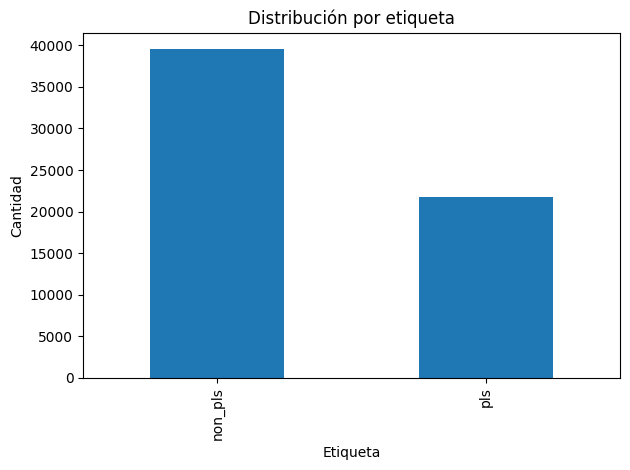

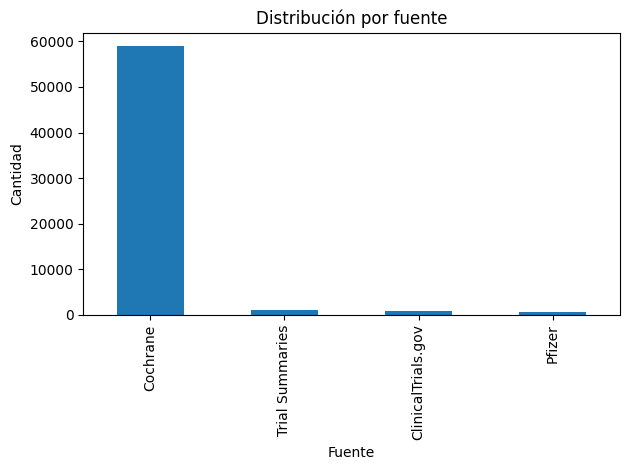

In [9]:

# === Resumen por etiqueta y fuente ===
if df.empty:
    raise SystemExit('No hay datos para continuar. Ajusta la configuración de rutas.')

print('\nDistribución por etiqueta:')
print(df['label'].value_counts())

print('\nDistribución por fuente:')
print(df['source'].value_counts())

# Plot 1: distribución por etiqueta
counts = df['label'].value_counts().sort_index()
plt.figure()
counts.plot(kind='bar')
plt.title('Distribución por etiqueta')
plt.xlabel('Etiqueta')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

# Plot 2: distribución por fuente
src_counts = df['source'].value_counts()
plt.figure()
src_counts.plot(kind='bar')
plt.title('Distribución por fuente')
plt.xlabel('Fuente')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()


## 7. Partición de conjuntos
Respeta splits existentes cuando los hay y genera divisiones train/test coherentes si faltan.

In [10]:

# === Partición Train/Test consolidada (respetando splits existentes) ===
def make_splits(df: pd.DataFrame, default_test_size=0.2, random_state=17) -> Tuple[pd.DataFrame, pd.DataFrame]:
    # Si una fila ya tiene subset 'train' o 'test', la respetamos.
    has_any_split = df['subset'].isin(['train', 'test']).any()
    if has_any_split:
        df_train = df[df['subset'] == 'train'].copy()
        df_test  = df[df['subset'] == 'test'].copy()
        df_uns   = df[df['subset'] == 'unspecified'].copy()

        # Para 'unspecified', hacemos split estratificado por etiqueta dentro de cada fuente
        parts_train = [df_train]
        parts_test  = [df_test]

        if not df_uns.empty:
            for src, group in df_uns.groupby('source'):
                if group['label_int'].nunique() == 1 or len(group) < 5:
                    # Muy pocos o sin variedad: lo mandamos todo a train
                    parts_train.append(group)
                else:
                    gtr, gte = train_test_split(group, test_size=default_test_size,
                                                random_state=random_state, stratify=group['label_int'])
                    parts_train.append(gtr)
                    parts_test.append(gte)
        df_train = pd.concat(parts_train, ignore_index=True)
        df_test  = pd.concat(parts_test, ignore_index=True)
    else:
        # Sin splits previos: split global estratificado
        df_train, df_test = train_test_split(df, test_size=default_test_size,
                                             random_state=random_state, stratify=df['label_int'])
    df_train = shuffle(df_train, random_state=random_state).reset_index(drop=True)
    df_test  = shuffle(df_test,  random_state=random_state).reset_index(drop=True)
    return df_train, df_test

df_train, df_test = make_splits(df, DEFAULT_TEST_SIZE, RANDOM_STATE)

print('Tamaños -> train:', len(df_train), '| test:', len(df_test))
print('\nTrain por etiqueta:')
print(df_train['label'].value_counts())
print('\nTest por etiqueta:')
print(df_test['label'].value_counts())

# Guardar snapshot
df.to_csv(OUTPUT_DIR / 'dataset_all.csv', index=False)
df_train.to_csv(OUTPUT_DIR / 'dataset_train.csv', index=False)
df_test.to_csv(OUTPUT_DIR / 'dataset_test.csv', index=False)


Tamaños -> train: 49481 | test: 11844

Train por etiqueta:
label
non_pls    31734
pls        17747
Name: count, dtype: int64

Test por etiqueta:
label
non_pls    7791
pls        4053
Name: count, dtype: int64


## 8. Modelos base
Construye pipelines TF-IDF con regresión logística y SVM lineal, incluyendo vectorización de palabras y caracteres.

In [11]:

# === Modelos base ===
def identity(x):
    return x

def build_vectorizer_union():
    # Dos vistas: palabras y caracteres (captura estilo, longitud, jergas, etc.)
    word_v = ('word_tfidf', TfidfVectorizer(
        analyzer='word',
        ngram_range=(1,2),
        min_df=3,
        max_df=0.9,
        strip_accents='unicode',
        lowercase=True,
        sublinear_tf=True
    ))
    char_v = ('char_tfidf', TfidfVectorizer(
        analyzer='char',
        ngram_range=(3,5),
        min_df=3,
        max_df=0.95,
        lowercase=True,
        sublinear_tf=True
    ))
    # FeatureUnion requiere duplicar el input, por eso usamos FunctionTransformer
    union = FeatureUnion([
        ('pass_through_word', Pipeline([('id1', FunctionTransformer(func=identity, validate=False)), word_v])),
        ('pass_through_char', Pipeline([('id2', FunctionTransformer(func=identity, validate=False)), char_v]))
    ])
    return union

def build_logreg_pipeline(C=2.0, class_weight='balanced', max_iter=2000):
    vec = build_vectorizer_union()
    clf = LogisticRegression(C=C, class_weight=class_weight, max_iter=max_iter, n_jobs=None, solver='saga')
    pipe = Pipeline([
        ('features', vec),
        ('clf', clf)
    ])
    return pipe

def build_svm_pipeline(C=1.0):
    vec = build_vectorizer_union()
    # LinearSVC no da probas; lo calibramos si queremos ROC/AUC
    base = Pipeline([('features', vec), ('clf', LinearSVC(C=C))])
    clf = CalibratedClassifierCV(base, cv=3, method='sigmoid')
    pipe = Pipeline([('calibrated', clf)])
    return pipe

MODELS = {
    'logreg_tfidf_wordchar': build_logreg_pipeline(C=2.0),
    'svm_linear_tfidf_wordchar': build_svm_pipeline(C=1.0)
}
list(MODELS.keys())


['logreg_tfidf_wordchar', 'svm_linear_tfidf_wordchar']

## 9. Entrenamiento y métricas
Ajusta los modelos, registra Accuracy, Precision, Recall, F1 y guarda resultados intermedios.


Entrenando: logreg_tfidf_wordchar
Acc: 0.9971 | Prec(macro): 0.9958 | Rec(macro): 0.9978 | F1(macro): 0.9968 | AUC: 0.9998951449449334

Classification Report:
               precision    recall  f1-score   support

     non_pls       1.00      1.00      1.00      7791
         pls       0.99      1.00      1.00      4053

    accuracy                           1.00     11844
   macro avg       1.00      1.00      1.00     11844
weighted avg       1.00      1.00      1.00     11844



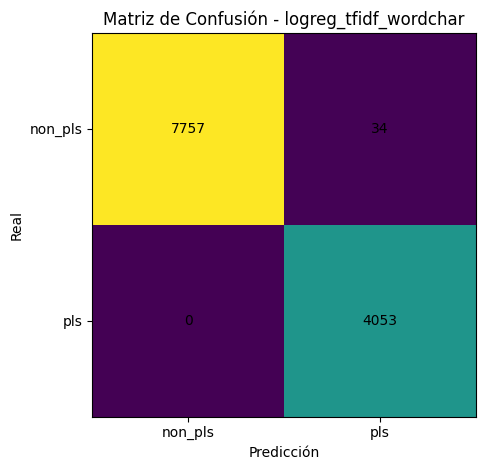


Entrenando: svm_linear_tfidf_wordchar
Acc: 0.9973 | Prec(macro): 0.9963 | Rec(macro): 0.9978 | F1(macro): 0.9970 | AUC: 0.9999336224115314

Classification Report:
               precision    recall  f1-score   support

     non_pls       1.00      1.00      1.00      7791
         pls       0.99      1.00      1.00      4053

    accuracy                           1.00     11844
   macro avg       1.00      1.00      1.00     11844
weighted avg       1.00      1.00      1.00     11844



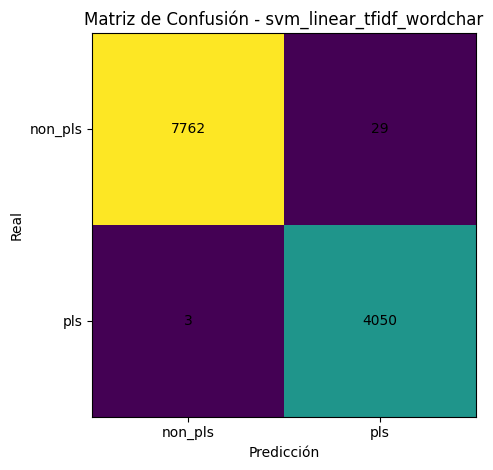

,model,accuracy,precision_macro,recall_macro,f1_macro,auc_roc,train_time_sec
0,svm_linear_tfidf_wordchar,0.997298,0.996252,0.997769,0.997004,0.999934,1728.467679
1,logreg_tfidf_wordchar,0.997129,0.995840,0.997818,0.996818,0.999895,2369.658796


In [12]:

# === Entrenamiento ===
X_train = df_train['text'].tolist()
y_train = df_train['label_int'].astype(int).values
X_test  = df_test['text'].tolist()
y_test  = df_test['label_int'].astype(int).values

results = []
trained_models = {}

for name, model in MODELS.items():
    print(f'\nEntrenando: {name}')
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    # Predicciones
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)

    # Probabilidades (si están disponibles) para AUC
    auc = None
    try:
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)[:, 1]
        else:
            # Si el pipeline es calibrado, tendrá predict_proba
            y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    except Exception:
        pass

    print(f'Acc: {acc:.4f} | Prec(macro): {prec:.4f} | Rec(macro): {rec:.4f} | F1(macro): {f1:.4f} | AUC: {auc}')
    print('\nClassification Report:\n', classification_report(y_test, y_pred, target_names=['non_pls','pls']))

    # Guardar matriz de confusión
    cm = confusion_matrix(y_test, y_pred, labels=[0,1])
    cm_df = pd.DataFrame(cm, index=['non_pls','pls'], columns=['pred_non_pls','pred_pls'])
    cm_path = OUTPUT_DIR / f'cm_{name}.csv'
    cm_df.to_csv(cm_path, index=True)

    # Plot y guardar imagen
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(f'Matriz de Confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.xticks([0,1], ['non_pls','pls'])
    plt.yticks([0,1], ['non_pls','pls'])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha='center', va='center')
    plt.tight_layout()
    fig_path = OUTPUT_DIR / f'cm_{name}.png'
    plt.savefig(fig_path, dpi=140)
    plt.show()

    results.append({
        'model': name,
        'accuracy': acc,
        'precision_macro': prec,
        'recall_macro': rec,
        'f1_macro': f1,
        'auc_roc': auc,
        'train_time_sec': train_time
    })
    trained_models[name] = model

res_df = pd.DataFrame(results).sort_values(by='f1_macro', ascending=False).reset_index(drop=True)
res_df.to_csv(OUTPUT_DIR / 'model_results.csv', index=False)
res_df


## 10. Curva ROC
Dibuja la curva ROC y calcula el AUC para el mejor clasificador con probabilidades disponibles.

Mejor modelo: svm_linear_tfidf_wordchar


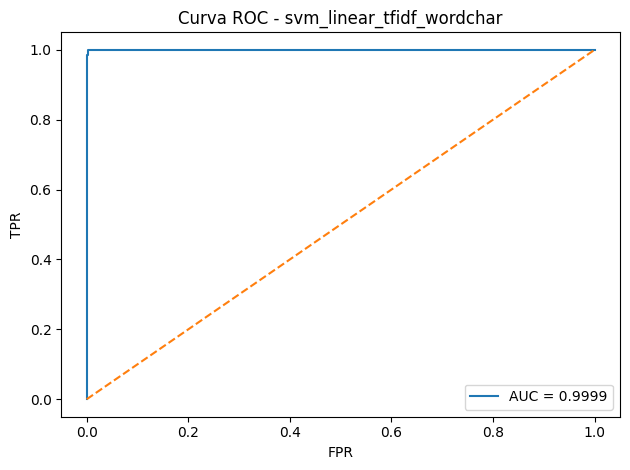

In [13]:

# === Curva ROC del mejor modelo (si tiene predict_proba) ===
best_row = res_df.iloc[0]
best_name = best_row['model']
best_model = trained_models[best_name]
print('Mejor modelo:', best_name)

try:
    y_proba = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, thr = roc_curve(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.4f}')
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title(f'Curva ROC - {best_name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'roc_{best_name}.png', dpi=140)
    plt.show()
except Exception as e:
    print('No fue posible calcular ROC/AUC para el mejor modelo:', e)


## 11. Palabras y caracteres indicativos
Inspecciona pesos de la regresión logística para identificar términos que más influyen en cada clase.

In [14]:

# === Palabras/caracteres más indicativos (solo LogReg) ===
def top_features_logreg(pipeline: Pipeline, k=30) -> Tuple[pd.DataFrame, pd.DataFrame]:
    # pipeline: ('features' -> FeatureUnion(Tfidf...)), ('clf' -> LogisticRegression)
    clf = None
    vec = None
    try:
        clf = pipeline.named_steps['clf']
        vec_union = pipeline.named_steps['features']
    except Exception:
        return (pd.DataFrame(), pd.DataFrame())

    if not hasattr(clf, 'coef_'):
        return (pd.DataFrame(), pd.DataFrame())

    # Extraer vocabulario combinado
    # Necesitamos concatenar los nombres de características de ambos TfidfVectorizer
    feat_names = []
    for name, sub in vec_union.transformer_list:
        # sub es un Pipeline([('id*', FunctionTransformer), ('word_tfidf'/ 'char_tfidf', TfidfVectorizer)])
        try:
            v = sub.named_steps.get('word_tfidf') or sub.named_steps.get('char_tfidf')
            names = list(v.get_feature_names_out())
            feat_names.extend(names)
        except Exception:
            continue

    coefs = clf.coef_[0]
    idx_sorted = np.argsort(coefs)

    top_non_pls = [(feat_names[i], coefs[i]) for i in idx_sorted[:k]]
    top_pls     = [(feat_names[i], coefs[i]) for i in idx_sorted[-k:][::-1]]

    df_non = pd.DataFrame(top_non_pls, columns=['feature','coef'])
    df_pls = pd.DataFrame(top_pls, columns=['feature','coef'])
    return df_non, df_pls

best_lr = trained_models.get('logreg_tfidf_wordchar')
if best_lr is not None:
    non_pls_feats, pls_feats = top_features_logreg(best_lr, k=30)
    print('Top rasgos -> NO PLS')
    display(non_pls_feats)
    print('Top rasgos -> PLS')
    display(pls_feats)
else:
    print('No hay modelo LogReg entrenado para listar rasgos.')


Top rasgos -> NO PLS


,feature,coef
0,ci,-3.662381
1,95,-3.426216
2,objectives,-3.269245
3,95 ci,-3.176889
4,objectives to,-2.887095
5,search methods,-2.830937
6,data,-2.824482
7,criteria,-2.739588
8,selection,-2.687493
9,the cochrane,-2.673798


Top rasgos -> PLS


,feature,coef
0,what,3.220404
1,study characteristics,2.781785
2,key results,2.590742
3,review question,2.518161
4,key,2.483968
5,question,2.476136
6,characteristics,2.415097
7,characteristics we,2.057771
8,blood,1.933597
9,can,1.873204


## 12. Análisis de errores
Muestra ejemplos de falsos positivos y falsos negativos para revisar fallos del modelo.

In [19]:

# === Análisis de errores: falsos positivos/negativos ===
def error_analysis(model, X_test, y_test, df_test_meta: pd.DataFrame, max_rows=10):
    y_pred = model.predict(X_test)
    err_idx = np.where(y_pred != y_test)[0]
    errs = df_test_meta.iloc[err_idx].copy()
    errs['y_true'] = y_test[err_idx]
    errs['y_pred'] = y_pred[err_idx]
    return errs.head(max_rows)

# Guardamos algunas filas de error del mejor modelo
best_model = trained_models[best_name]
err_df = error_analysis(best_model, X_test, y_test, df_test, max_rows=20)
err_df[['source','subset','label','y_true','y_pred','n_chars','path']].to_csv(OUTPUT_DIR / f'errors_{best_name}.csv', index=False)
err_df


,text,label,source,subset,path,label_int,n_chars,y_true,y_pred
230,Background\nThere is increasing focus on provi...,non_pls,Cochrane,test,bridging-the-gap-in-health-literacy-main/data_...,0,1990,0,1
577,The grooved pegboard test was a manipulative d...,non_pls,ClinicalTrials.gov,test,bridging-the-gap-in-health-literacy-main/data_...,0,2763,0,1
653,Background\nA Class II division 2 malocclusion...,non_pls,Cochrane,test,bridging-the-gap-in-health-literacy-main/data_...,0,1677,0,1
970,Antidotes for acute cardenolide (cardiac glyco...,pls,Cochrane,test,bridging-the-gap-in-health-literacy-main/data_...,1,2526,1,0
1003,Background\nThis systematic review focuses on ...,non_pls,Cochrane,test,bridging-the-gap-in-health-literacy-main/data_...,0,1778,0,1
1155,"Demographic data in North America, Europe, Asi...",non_pls,Cochrane,test,bridging-the-gap-in-health-literacy-main/data_...,0,3213,0,1
1294,Background\nNocturnal enuresis (bedwetting) is...,non_pls,Cochrane,test,bridging-the-gap-in-health-literacy-main/data_...,0,1958,0,1
1504,The grooved pegboard test was a manipulative d...,non_pls,ClinicalTrials.gov,test,bridging-the-gap-in-health-literacy-main/data_...,0,5494,0,1
1540,The use of financial incentives to reward PCPs...,non_pls,Cochrane,test,bridging-the-gap-in-health-literacy-main/data_...,0,1711,0,1
1561,Endometrial cancer is the sixth most common ca...,non_pls,Cochrane,test,bridging-the-gap-in-health-literacy-main/data_...,0,2086,0,1


## 13. Exportación del pipeline
Guarda el pipeline ganador en formato joblib junto con metadatos para reutilizarlo.

In [16]:

# === Exportar el mejor modelo (joblib) ===
export_path = OUTPUT_DIR / f'best_model_{best_name}.joblib'
dump(best_model, export_path)
export_path


PosixPath('outputs_pls_classifier/best_model_svm_linear_tfidf_wordchar.joblib')

## 14. Demo de inferencia
Ejecuta una predicción rápida sobre un ejemplo de texto para comprobar el flujo completo.

In [17]:

# === Demo de inferencia ===
LABEL_INV = {0: 'non_pls', 1: 'pls'}

def predict_texts(model, texts: List[str]) -> pd.DataFrame:
    y_pred = model.predict(texts)
    out = pd.DataFrame({'text': texts, 'pred_label': [LABEL_INV[int(i)] for i in y_pred]})
    try:
        if hasattr(model, 'predict_proba'):
            proba = model.predict_proba(texts)[:,1]
        else:
            proba = model.predict_proba(texts)[:,1]
        out['prob_pls'] = proba
    except Exception:
        pass
    return out

demo_samples = [
    "This study evaluated the efficacy of adalimumab in a randomized, double-blind, placebo-controlled trial.",
    "We did a study to see if the medicine works. Half the people got the medicine and half didn't. We compared how they felt."
]

predict_texts(best_model, demo_samples)


,text,pred_label,prob_pls
0,This study evaluated the efficacy of adalimuma...,non_pls,0.124635
1,We did a study to see if the medicine works. H...,pls,0.998962
